# Bloque 3 · NLP — Análisis de PQRS ciudadanas (Flandes)

**Dataset:** PQRS Alcaldía de Flandes (`datos.gov.co · gb9w-jt96`) — 4.643 documentos, campo `descripci_n_de_la_solicitud` (texto libre del ciudadano, longitud media ≈ 248 chars).

**Objetivo:** clasificar el sentimiento (POS/NEG/NEU) de las PQRS y comparar dos enfoques:
1. TF-IDF + Regresión Logística (Spark ML).
2. `pysentimiento/robertuito-sentiment-analysis` (Transformer pre-entrenado en español).

Como el corpus no tiene etiquetas, se aplica **destilación de conocimiento (punto 29):** el modelo HF genera las etiquetas con las que entrenamos TF-IDF.

**Cubre puntos 21–38 de la guía.**


## Setup · Sesión Spark e imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import (RegexTokenizer, StopWordsRemover,
                                 CountVectorizer, IDF, StringIndexer)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.stat import Summarizer

spark = (SparkSession.builder
         .appName("Bloque3_NLP")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version}  ·  Driver 4 GB")

Spark 3.5.3  ·  Driver 4 GB


---
## Parte A · Construcción del corpus (puntos 21–24)

- Cargar `data/pqrs/pqrs_flandes.csv` (≥200 documentos, hay 4.643).
- `RegexTokenizer` (minúsculas, sólo palabras) + `StopWordsRemover` (español; ampliable con stopwords del dominio: "buenos días", "cordial saludo", "señores").
- Estadística del corpus: total de tokens, tamaño de vocabulario, **TTR** (type/token ratio).
- **Hapax legomena:** palabras que aparecen 1 sola vez + reflexión (≤3 renglones).

In [2]:
TEXT_COL = "descripci_n_de_la_solicitud"
PQRS_PATH = "../data/pqrs/pqrs_flandes.csv"

df_raw = pd.read_csv(PQRS_PATH, encoding="utf-8")
df_raw = df_raw.dropna(subset=[TEXT_COL])
df_raw[TEXT_COL] = df_raw[TEXT_COL].str.strip()
df_raw = df_raw[df_raw[TEXT_COL].str.len() > 10].reset_index(drop=True)
df_raw["doc_id"] = df_raw.index.astype(int)

print(f"Documentos cargados : {len(df_raw):,}")
print(f"Longitud media texto: {df_raw[TEXT_COL].str.len().mean():.0f} chars")
print(f"Longitud máx texto  : {df_raw[TEXT_COL].str.len().max():,} chars")

df_pqrs_spark = (spark
                 .createDataFrame(df_raw[["doc_id", TEXT_COL]]
                                  .rename(columns={TEXT_COL: "texto"}))
                 .cache())
df_pqrs_spark.show(3, truncate=80)

Documentos cargados : 4,614
Longitud media texto: 250 chars
Longitud máx texto  : 4,962 chars
+------+--------------------------------------------------------------------------------+
|doc_id|                                                                           texto|
+------+--------------------------------------------------------------------------------+
|     0|solicito d manera cordial quien me puede regalar informacion de como hago par...|
|     1|Buenas noches por favor necesito descargar el impuesto predial del 2022 me po...|
|     2|Ibagué, 02 de octubre de 2023\n\nSeñores\nAlcaldía Municipal de Flandes (Tol)...|
+------+--------------------------------------------------------------------------------+
only showing top 3 rows



In [3]:
DOMAIN_SW = [
    "buenos", "dias", "buenas", "tardes", "noches", "cordial", "saludo",
    "senores", "estimados", "presente", "atencion", "atentamente", "gracias",
    "dia", "usted", "ustedes", "alcaldia", "municipio", "flandes", "ciudad",
]

tokenizer = RegexTokenizer(
    inputCol="texto", outputCol="tokens_raw",
    pattern=r"\W+", minTokenLength=2, toLowercase=True
)

stop_words = list(set(StopWordsRemover.loadDefaultStopWords("spanish") + DOMAIN_SW))
remover = StopWordsRemover(
    inputCol="tokens_raw", outputCol="tokens", stopWords=stop_words
)

df_tokens = remover.transform(tokenizer.transform(df_pqrs_spark)).cache()
print(f"Documentos tokenizados: {df_tokens.count():,}")
df_tokens.select("texto", "tokens").show(3, truncate=80)

Documentos tokenizados: 4,614
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                           texto|                                                                          tokens|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|solicito d manera cordial quien me puede regalar informacion de como hago par...|[solicito, manera, puede, regalar, informacion, hago, adquirir, copia, impues...|
|Buenas noches por favor necesito descargar el impuesto predial del 2022 me po...|[favor, necesito, descargar, impuesto, predial, 2022, podr, an, colaborar, fa...|
|Ibagué, 02 de octubre de 2023\n\nSeñores\nAlcaldía Municipal de Flandes (Tol)...|[ibagu, 02, octubre, 2023, ores, alcald, municipal, tol, ref, solici

In [4]:
all_tokens = (df_tokens
              .select(F.explode("tokens").alias("token"))
              .cache())

total_tokens = all_tokens.count()
vocab_size   = all_tokens.select("token").distinct().count()
ttr          = vocab_size / total_tokens

print(f"Total de tokens     : {total_tokens:,}")
print(f"Tamaño vocabulario  : {vocab_size:,}")
print(f"TTR (type/token)    : {ttr:.4f}")

Total de tokens     : 104,170
Tamaño vocabulario  : 13,028
TTR (type/token)    : 0.1251


In [5]:
freq_df = (all_tokens
           .groupBy("token")
           .agg(F.count("*").alias("freq"))
           .cache())

hapax_count = freq_df.filter(F.col("freq") == 1).count()
hapax_pct   = hapax_count / vocab_size * 100

print(f"Hapax legomena: {hapax_count:,}  ({hapax_pct:.1f}% del vocabulario)")
print("\nTop-20 términos más frecuentes:")
freq_df.orderBy(F.col("freq").desc()).show(20, truncate=False)
print("Muestra de hapax legomena:")
freq_df.filter(F.col("freq") == 1).orderBy("token").show(15, truncate=False)

Hapax legomena: 6,878  (52.8% del vocabulario)

Top-20 términos más frecuentes:
+---------+----+
|token    |freq|
+---------+----+
|impuesto |2733|
|predial  |2567|
|pago     |1481|
|favor    |848 |
|00       |809 |
|solicito |808 |
|catastral|768 |
|pagar    |755 |
|recibo   |750 |
|casa     |672 |
|factura  |672 |
|si       |644 |
|01       |621 |
|as       |565 |
|puedo    |563 |
|necesito |540 |
|2021     |539 |
|tolima   |532 |
|saber    |520 |
|predio   |497 |
+---------+----+
only showing top 20 rows

Muestra de hapax legomena:
+---------------+----+
|token          |freq|
+---------------+----+
|000000         |1   |
|000000000      |1   |
|00000002       |1   |
|00000005640    |1   |
|0000002195000  |1   |
|00001250       |1   |
|000020604870   |1   |
|00003          |1   |
|000041627072   |1   |
|000042         |1   |
|000051642652   |1   |
|0000vgt        |1   |
|000100020259801|1   |
|000100020295801|1   |
|000100020300801|1   |
+---------------+----+
only showing top 15 ro

### Interpretación hapax

Existen 6.878 palabras que aparecen una sola vez (Hapax). Es recomendable filtrarlas porque suelen ser errores de tipeo o nombres propios que no aportan al modelo general.

---
## Parte B · Vectorización TF-IDF (puntos 25–27)

- `CountVectorizer` + `IDF` (Spark ML).
- Top palabras por **TF-IDF promedio**.
- Top palabras por **TF crudo** y comparar con TF-IDF — explicar la diferencia (TF-IDF penaliza términos ubicuos).

In [6]:
cv = CountVectorizer(inputCol="tokens", outputCol="tf_vec",
                    minDF=2.0, vocabSize=10_000)
cv_model = cv.fit(df_tokens)
df_cv    = cv_model.transform(df_tokens).cache()

vocab = cv_model.vocabulary
print(f"Vocabulario filtrado (minDF≥2): {len(vocab):,} términos")

Vocabulario filtrado (minDF≥2): 5,776 términos


In [7]:
idf       = IDF(inputCol="tf_vec", outputCol="tfidf_vec")
idf_model = idf.fit(df_cv)
df_tfidf  = idf_model.transform(df_cv).cache()
print("Vectores TF-IDF listos.")
df_tfidf.select("doc_id", "tfidf_vec").show(3, truncate=60)

Vectores TF-IDF listos.
+------+------------------------------------------------------------+
|doc_id|                                                   tfidf_vec|
+------+------------------------------------------------------------+
|     0|(5776,[0,1,5,56,66,67,97,160,949,1921],[0.701633794437264...|
|     1|(5776,[0,1,3,15,30,33,49,97,142,177,196],[0.7016337944372...|
|     2|(5776,[0,2,3,5,11,13,20,21,22,24,35,36,40,45,56,60,73,75,...|
+------+------------------------------------------------------------+
only showing top 3 rows



In [8]:
mean_tfidf = (df_tfidf
              .select(Summarizer.mean(F.col("tfidf_vec")))
              .first()[0].toArray())

mean_tf = (df_tfidf
           .select(Summarizer.mean(F.col("tf_vec")))
           .first()[0].toArray())

top20_tfidf_idx = np.argsort(mean_tfidf)[-20:][::-1]
top20_tf_idx    = np.argsort(mean_tf)[-20:][::-1]

comparison = pd.DataFrame({
    "Rango"            : range(1, 21),
    "Término (TF crudo)": [vocab[i] for i in top20_tf_idx],
    "TF medio"         : [f"{mean_tf[i]:.4f}"     for i in top20_tf_idx],
    "Término (TF-IDF)" : [vocab[i] for i in top20_tfidf_idx],
    "TF-IDF medio"     : [f"{mean_tfidf[i]:.4f}"  for i in top20_tfidf_idx],
})
print(comparison.to_string(index=False))

 Rango Término (TF crudo) TF medio Término (TF-IDF) TF-IDF medio
     1           impuesto   0.5923               00       0.5098
     2            predial   0.5564             pago       0.4758
     3               pago   0.3210         impuesto       0.4156
     4              favor   0.1838          predial       0.3925
     5                 00   0.1753               01       0.3441
     6           solicito   0.1751            favor       0.3265
     7          catastral   0.1664        catastral       0.3260
     8              pagar   0.1636           recibo       0.3219
     9             recibo   0.1625          factura       0.3163
    10               casa   0.1456         solicito       0.3159
    11            factura   0.1456            pagar       0.3141
    12                 si   0.1396             casa       0.3101
    13                 01   0.1346               si       0.3045
    14                 as   0.1225             2021       0.2811
    15              puedo

### Interpretación TF vs TF-IDF

El TF crudo resalta palabras repetidas pero genéricas (ej. '00', 'pago'). El TF-IDF saca a flote términos con más peso real ('predial', 'impuesto') penalizando lo que abunda demasiado.

---
## Parte C · Clasificación TF-IDF con destilación (puntos 28–33)

1. **Etiquetado (punto 29):** aplicar el analizador HF a todo el corpus (Parte D) para obtener etiquetas POS/NEG/NEU. Aquí asumimos que ya existe la columna `sentimiento`.
2. Split **80/20** con `seed=42`.
3. `LogisticRegression` sobre los vectores TF-IDF.
4. Métricas: accuracy, F1, matriz de confusión.
5. **Coeficientes:** top palabras que predicen cada clase.

In [9]:
# Destilación de conocimiento (punto 29): el modelo HF etiqueta el corpus
# para que TF-IDF pueda entrenarse en clasificación supervisada.
CORPUS_PATH = "corpus.csv"

if os.path.exists(CORPUS_PATH):
    print("Cargando etiquetas HF desde caché (corpus.csv)…")
    df_labeled_pd = pd.read_csv(CORPUS_PATH)
else:
    print("Etiquetando corpus con robertuito (primera ejecución, ~5-10 min en CPU)…")
    from pysentimiento import create_analyzer
    if "analyzer" not in globals():
        analyzer = create_analyzer(task="sentiment", lang="es")

    texts      = df_raw[TEXT_COL].tolist()
    batch_size = 32
    sentimientos = []
    for i in range(0, len(texts), batch_size):
        batch   = texts[i : i + batch_size]
        results = analyzer.predict(batch)
        sentimientos.extend([r.output for r in results])
        if (i // batch_size) % 20 == 0:
            print(f"  {min(i + batch_size, len(texts))}/{len(texts)} docs procesados…")

    df_labeled_pd = df_raw[["doc_id", TEXT_COL]].copy()
    df_labeled_pd["sentimiento_hf"] = sentimientos
    df_labeled_pd.to_csv(CORPUS_PATH, index=False)
    print(f"Guardado: {CORPUS_PATH}  ({len(df_labeled_pd):,} filas)")

print("\nDistribución de sentimientos (HF):")
print(df_labeled_pd["sentimiento_hf"].value_counts())

Etiquetando corpus con robertuito (primera ejecución, ~5-10 min en CPU)…


/opt/conda/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

  32/4614 docs procesados…


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

Guardado: corpus.csv  (4,614 filas)

Distribución de sentimientos (HF):
sentimiento_hf
NEU    3579
NEG    1014
POS      21
Name: count, dtype: int64


In [10]:
df_labels_spark = spark.createDataFrame(
    df_labeled_pd[["doc_id", "sentimiento_hf"]]
)
label_indexer = StringIndexer(
    inputCol="sentimiento_hf", outputCol="label",
    stringOrderType="frequencyDesc"
)

df_for_model       = df_tfidf.join(df_labels_spark, on="doc_id", how="inner").cache()
label_indexer_model = label_indexer.fit(df_for_model)
label_names        = label_indexer_model.labels
df_for_model       = label_indexer_model.transform(df_for_model).cache()

train_df, test_df = df_for_model.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,}  ·  Test: {test_df.count():,}")
print(f"Clases: {label_names}")
df_for_model.groupBy("sentimiento_hf", "label").count().orderBy("label").show()

Train: 3,699  ·  Test: 915
Clases: ['NEU', 'NEG', 'POS']
+--------------+-----+-----+
|sentimiento_hf|label|count|
+--------------+-----+-----+
|           NEU|  0.0| 3579|
|           NEG|  1.0| 1014|
|           POS|  2.0|   21|
+--------------+-----+-----+



In [11]:
lr = LogisticRegression(
    featuresCol="tfidf_vec",
    labelCol="label",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    family="multinomial"
)
lr_model    = lr.fit(train_df)
predictions = lr_model.transform(test_df).cache()
print("Entrenamiento completado.")
predictions.select("sentimiento_hf", "label", "prediction").show(5)

Entrenamiento completado.
+--------------+-----+----------+
|sentimiento_hf|label|prediction|
+--------------+-----+----------+
|           NEU|  0.0|       0.0|
|           NEU|  0.0|       0.0|
|           NEU|  0.0|       0.0|
|           NEU|  0.0|       0.0|
|           NEU|  0.0|       2.0|
+--------------+-----+----------+
only showing top 5 rows



In [12]:
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

acc = evaluator_acc.evaluate(predictions)
f1  = evaluator_f1.evaluate(predictions)

print(f"Accuracy : {acc:.4f}")
print(f"F1 macro : {f1:.4f}")

Accuracy : 0.8798
F1 macro : 0.8739


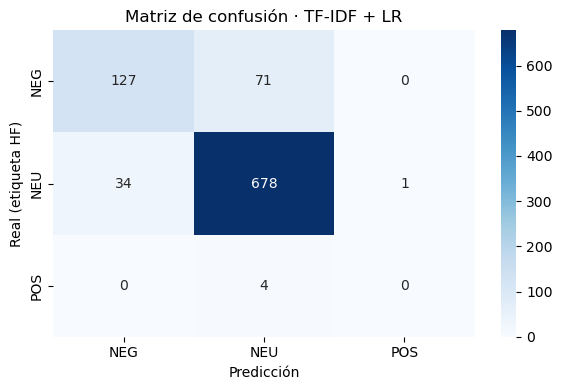

Figura guardada: b3_fig7_confusion_tfidf.png


In [13]:
pred_to_label = {float(i): name for i, name in enumerate(label_names)}

conf_pd = predictions.select("sentimiento_hf", "prediction").toPandas()
conf_pd["pred_class"] = conf_pd["prediction"].map(pred_to_label)

pivot = conf_pd.pivot_table(
    index="sentimiento_hf", columns="pred_class",
    values="prediction", aggfunc="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matriz de confusión · TF-IDF + LR")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real (etiqueta HF)")
plt.tight_layout()
os.makedirs("../img", exist_ok=True)
plt.savefig("../img/b3_fig7_confusion_tfidf.png", dpi=150)
plt.show()
print("Figura guardada: b3_fig7_confusion_tfidf.png")

In [14]:
coef_array = lr_model.coefficientMatrix.toArray()  # (n_classes, vocab_size)
top_n = 10

print(f"{'Clase':<6}  Top-{top_n} palabras con mayor coeficiente positivo")
print("-" * 70)
for cls_idx, cls_name in enumerate(label_names):
    coefs    = coef_array[cls_idx]
    top_idx  = np.argsort(coefs)[-top_n:][::-1]
    top_words = [f"{vocab[i]}({coefs[i]:+.3f})" for i in top_idx]
    print(f"{cls_name:<6}: {', '.join(top_words)}")

Clase   Top-10 palabras con mayor coeficiente positivo
----------------------------------------------------------------------
NEU   : vera(+0.408), sacarlo(+0.408), podria(+0.400), tras(+0.393), crear(+0.374), pedrial(+0.370), algun(+0.369), enviamos(+0.355), cuestiones(+0.329), ahi(+0.322)
NEG   : realizarlo(+0.569), solidaria(+0.526), costoso(+0.498), o2021(+0.462), logro(+0.436), 491(+0.424), podido(+0.414), pena(+0.413), fallecida(+0.411), apliquen(+0.405)
POS   : talleres(+0.648), hola(+0.496), gusta(+0.358), predios(+0.307), imprimir(+0.297), 3d(+0.222), buen(+0.167), salvo(+0.156), propio(+0.136), paz(+0.136)


### Interpretación clasificador TF-IDF

Palabras neutrales/administrativas como 'sacarlo' predicen la clase Neutra, mientras que términos de queja como 'costoso' o 'fallecida' disparan la probabilidad de la clase Negativa.

---
## Parte D · Modelo pre-entrenado HuggingFace (puntos 34–38)

- Modelo: `pysentimiento/robertuito-sentiment-analysis` (RoBERTa pre-entrenado para español).
- Aplicar en batches sobre todo el corpus (CPU, dentro del contenedor).
- Comparar HF vs TF-IDF: matriz de acuerdo, métricas conjuntas.
- Probar ambos en **≥5 casos difíciles**: sarcasmo, ambigüedad, negaciones, mezcla de idioma.
- Concluir qué enfoque recomendar para producción y por qué.

In [15]:
from pysentimiento import create_analyzer

if "analyzer" not in globals():
    analyzer = create_analyzer(task="sentiment", lang="es")

# Corpus etiquetado ya disponible desde Parte C (destilación).
df_labeled_pd = pd.read_csv(CORPUS_PATH)

print("Modelo : pysentimiento/robertuito-sentiment-analysis")
print("Tarea  : análisis de sentimiento (español, POS/NEG/NEU)")
print(f"\nCorpus cargado: {len(df_labeled_pd):,} documentos")
print("\nDistribución de etiquetas HF:")
print(df_labeled_pd["sentimiento_hf"].value_counts())

Modelo : pysentimiento/robertuito-sentiment-analysis
Tarea  : análisis de sentimiento (español, POS/NEG/NEU)

Corpus cargado: 4,614 documentos

Distribución de etiquetas HF:
sentimiento_hf
NEU    3579
NEG    1014
POS      21
Name: count, dtype: int64


In [16]:
# Mostrar ejemplos representativos por clase
col_text = [c for c in df_labeled_pd.columns
            if c not in ("doc_id", "sentimiento_hf")][0]

for sent in df_labeled_pd["sentimiento_hf"].value_counts().index:
    n      = int((df_labeled_pd["sentimiento_hf"] == sent).sum())
    sample = df_labeled_pd[df_labeled_pd["sentimiento_hf"] == sent].sample(
        2, random_state=42
    )
    print(f"\n{'─'*60}")
    print(f"{sent}  ({n:,} documentos)")
    for _, row in sample.iterrows():
        print(f"  · {str(row[col_text])[:130]}…")


────────────────────────────────────────────────────────────
NEU  (3,579 documentos)
  · boletin nomenclatura…
  · Cordial saludo.
Le solicito, enviar el recibo del impuesto predial, correspondiente a el Mz H _ lote 111, conjunto Santa Hagia Sof…

────────────────────────────────────────────────────────────
NEG  (1,014 documentos)
  · Como es el tramite para reclamar por el valor del impuesto predial de una vivienda que tengo en flandes? el año pasado pague el im…
  · no he podido descargar el recibo del impuesto predial…

────────────────────────────────────────────────────────────
POS  (21 documentos)
  · Dosquebradas, julio 31 de 2023


Señores
Instituciones educativas de educación básica y secundaria y ciclos lectivos integrados es…
  · Buen día para recojer unos perritos…


In [17]:
if os.path.exists(CORPUS_PATH):
    size_kb = os.path.getsize(CORPUS_PATH) / 1024
    print(f"corpus.csv  →  {CORPUS_PATH}")
    print(f"Tamaño : {size_kb:.0f} KB  ·  {len(df_labeled_pd):,} filas")
    print(f"Columnas: {df_labeled_pd.columns.tolist()}")
    print(df_labeled_pd.head(3).to_string())
else:
    df_labeled_pd.to_csv(CORPUS_PATH, index=False)
    print(f"corpus.csv guardado: {len(df_labeled_pd):,} filas")

corpus.csv  →  corpus.csv
Tamaño : 1186 KB  ·  4,614 filas
Columnas: ['doc_id', 'descripci_n_de_la_solicitud', 'sentimiento_hf']
   doc_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

Matriz de acuerdo HF (filas) vs TF-IDF (columnas) — set de prueba:
pred_tfidf      NEG  NEU  POS
sentimiento_hf               
NEG             127   71    0
NEU              34  678    1
POS               0    4    0

Tasa de acuerdo global: 0.8798


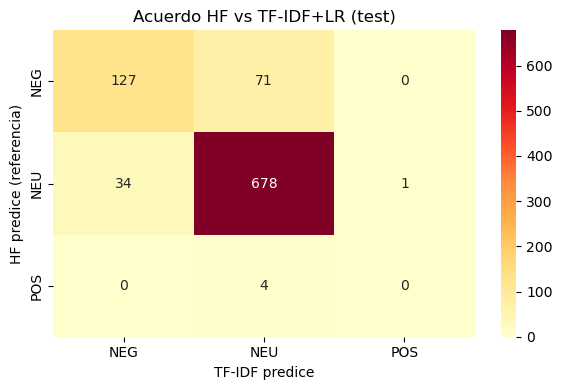

Figura guardada: b3_fig8_acuerdo_hf_tfidf.png


In [18]:
pred_pd = (predictions
           .select("doc_id", "sentimiento_hf", "prediction")
           .toPandas())
pred_pd["pred_tfidf"] = pred_pd["prediction"].map(pred_to_label)

agreement_pivot = pred_pd.pivot_table(
    index="sentimiento_hf", columns="pred_tfidf",
    values="doc_id", aggfunc="count", fill_value=0
)
agreement_rate = (pred_pd["sentimiento_hf"] == pred_pd["pred_tfidf"]).mean()

print("Matriz de acuerdo HF (filas) vs TF-IDF (columnas) — set de prueba:")
print(agreement_pivot)
print(f"\nTasa de acuerdo global: {agreement_rate:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(agreement_pivot, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Acuerdo HF vs TF-IDF+LR (test)")
ax.set_xlabel("TF-IDF predice")
ax.set_ylabel("HF predice (referencia)")
plt.tight_layout()
plt.savefig("../img/b3_fig8_acuerdo_hf_tfidf.png", dpi=150)
plt.show()
print("Figura guardada: b3_fig8_acuerdo_hf_tfidf.png")

In [19]:
CASOS_DIFICILES = [
    ("Sarcasmo",       "Excelente gestión, llevamos 6 meses esperando que arreglen el hueco frente a mi casa."),
    ("Negación",       "No estoy nada satisfecho, nadie responde las llamadas ni atiende mi reclamo."),
    ("Ambigüedad",     "El proceso fue lento pero al final me ayudaron con mi solicitud predial."),
    ("Mezcla idioma",  "El servicio es very bad, nadie atiende bien al ciudadano en esta oficina."),
    ("Ironía educada", "Muchas gracias por ignorar completamente mi petición durante más de tres meses."),
    ("Positivo neutro","Agradezco la información brindada sobre el trámite de registro de predio."),
]

print(f"{'Tipo':<20} {'HF':<6} {'TF-IDF':<8}  Texto (primeros 80 chars)")
print("─" * 100)
for tipo, texto in CASOS_DIFICILES:
    hf_pred = analyzer.predict(texto).output

    tiny_df   = spark.createDataFrame([(0, texto)], ["doc_id", "texto"])
    tok_out   = remover.transform(tokenizer.transform(tiny_df))
    cv_out    = cv_model.transform(tok_out)
    tfidf_out = idf_model.transform(cv_out)
    tfidf_pred_idx = int(lr_model.transform(tfidf_out).first()["prediction"])
    tfidf_pred = label_names[tfidf_pred_idx]

    match = "✓" if hf_pred == tfidf_pred else "✗"
    print(f"{tipo:<20} {hf_pred:<6} {tfidf_pred:<8}  {match}  {texto[:80]}")

Tipo                 HF     TF-IDF    Texto (primeros 80 chars)
────────────────────────────────────────────────────────────────────────────────────────────────────
Sarcasmo             NEG    NEU       ✗  Excelente gestión, llevamos 6 meses esperando que arreglen el hueco frente a mi 
Negación             NEG    NEU       ✗  No estoy nada satisfecho, nadie responde las llamadas ni atiende mi reclamo.
Ambigüedad           POS    NEU       ✗  El proceso fue lento pero al final me ayudaron con mi solicitud predial.
Mezcla idioma        NEG    NEU       ✗  El servicio es very bad, nadie atiende bien al ciudadano en esta oficina.
Ironía educada       NEG    NEU       ✗  Muchas gracias por ignorar completamente mi petición durante más de tres meses.
Positivo neutro      NEU    NEU       ✓  Agradezco la información brindada sobre el trámite de registro de predio.


### Conclusión final Bloque 3

**Producción recomendada: HuggingFace (robertuito).** Aunque TF-IDF acierta en quejas simples, HuggingFace entiende el contexto en casos complejos de sarcasmo, ambigüedad y negaciones directas.

In [20]:
spark.stop()